In [2]:
import numpy as np
import random
import datetime
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import math
import pandas as pd
import os
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf

random.seed(42)
np.random.seed(42)

import osmnx as ox
import networkx as nx

# Make OSMnx use cache (faster after first time)
ox.settings.use_cache = True
ox.settings.log_console = True


ModuleNotFoundError: No module named 'matplotlib'

In [74]:
# Load FINAL model
model = load_model("../models/densenet121_final.keras", compile=False)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
print("Final model loaded successfully.")

forecast_model = joblib.load("../models/fill_forecast_rf.pkl")
print("Forecast model loaded:", type(forecast_model))
print("Forecast model features:", forecast_model.feature_names_in_)

Final model loaded successfully.
Forecast model loaded: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Forecast model features: ['fill_level' 'hour_of_day' 'day' 'weekend' 'growth_rate' 'lag_1' 'lag_2'
 'lag_3' 'rolling_mean_3']


In [67]:
DATASET_DIR = "../data/images"
IMG_SIZE = (224, 224)

datagen = ImageDataGenerator(rescale=1./255)

generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=1,
    class_mode="categorical",
    shuffle=False
)

class_names = list(generator.class_indices.keys())

print("Classes:", class_names)


Found 2527 images belonging to 6 classes.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [68]:
def simulate_iot_data(bin_id):
    return {
        "bin_id": bin_id,
        "fill_level": random.randint(10, 100),  # percentage
        "location": f"Sector {random.choice(['A', 'B', 'C'])}",
        "last_collection_hours": random.randint(1, 48),
        "timestamp": datetime.datetime.now()
    }


In [69]:
def predict_future_fill(current_fill, hour, day, weekend=0):
    import pandas as pd
    input_data = pd.DataFrame([{
        "fill_level": current_fill,
        "hour_of_day": hour,
        "day": day,
        "weekend": weekend
    }])
    return float(forecast_model.predict(input_data)[0])


In [70]:
def calculate_priority_score(confidence, bin_data):

    predicted_fill = predict_future_fill(
        current_fill=bin_data["fill_level"],
        hour=datetime.datetime.now().hour,
        day=0
    )

    fill_weight = 0.5
    time_weight = 0.3
    confidence_weight = 0.2

    fill_score = predicted_fill / 100
    time_score = bin_data["last_collection_hours"] / 48
    confidence_score = 1 - confidence

    priority_score = (
        fill_weight * fill_score +
        time_weight * time_score +
        confidence_weight * confidence_score
    )

    return round(priority_score, 2), round(predicted_fill, 1)


In [71]:
def process_bin(bin_id, img_path):

    from tensorflow.keras.preprocessing import image

    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    pred_class = class_names[np.argmax(pred)]
    confidence = float(np.max(pred))

    bin_data = simulate_iot_data(bin_id)

    priority_score, predicted_fill = calculate_priority_score(confidence, bin_data)

    return {
        "bin_id": bin_id,
    "waste_type": pred_class,
    "confidence": round(confidence, 2),
    "fill_level": bin_data["fill_level"],
    "predicted_fill": predicted_fill,
    "location": bin_data["location"],
    "last_collection_hours": bin_data["last_collection_hours"],
    "priority_score": priority_score
    }


In [72]:
test_image = "../data/images/plastic/plastic32.jpg"

bins = ["BIN_101", "BIN_102", "BIN_103"]

results = []

for b in bins:
    results.append(process_bin(b, test_image))

# Sort by priority score (highest first)
results = sorted(results, key=lambda x: x["priority_score"], reverse=True)

for r in results:
    print("\n--- Smart Bin Priority Report ---")
    for k, v in r.items():
        print(f"{k}: {v}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- growth_rate
- lag_1
- lag_2
- lag_3
- rolling_mean_3


In [12]:
# Use the already-built results as routing input
reports = results.copy()

print("Routing input bins:", len(reports))
print(reports[0])


Routing input bins: 3
{'bin_id': 'BIN_102', 'waste_type': 'plastic', 'confidence': 1.0, 'fill_level': 50, 'predicted_fill': 57.9, 'location': 'Sector B', 'last_collection_hours': 18, 'priority_score': 0.4}


In [13]:
# Build a list of random images from dataset folders
image_paths = []
for cls in class_names:
    cls_dir = os.path.join(DATASET_DIR, cls)
    for f in os.listdir(cls_dir):
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(cls_dir, f))

print("Total images found:", len(image_paths))

# Create 10 bins and process each with a random image
bins = [f"BIN_{101+i}" for i in range(10)]
results = []

for b in bins:
    img_path = random.choice(image_paths)
    results.append(process_bin(b, img_path))

# Sort by priority (highest first)
results = sorted(results, key=lambda x: x["priority_score"], reverse=True)

print("Generated smart bin reports:", len(results))
print(results[0])

Total images found: 2527
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
Generated smart bin reports: 10
{'bin_id': 'BIN_108', 'waste_type': 'glass', 'confidence': 0.93, 'fill_level': 90, 'predicted_fill': 95.5, 'location': 'Sector A', 'last_collection_hours': 44, 'priority_score': 0.77}


In [1]:
# Example depot location (Hull)
DEPOT = (53.7450, -0.3350)   # Hull City Centre

# Give each sector a base coordinate
sector_coords = {
    "Sector A": (53.7440, -0.3300),  # HU1 / City Centre
    "Sector B": (53.7600, -0.3800),  # West Hull (HU4/HU5 area)
    "Sector C": (53.8000, -0.3000),  # North-East (HU6/HU7)
}

for r in results:
    base = sector_coords[r["location"]]
    # small random noise to make each bin unique
    r["coordinates"] = (
        base[0] + random.uniform(-0.01, 0.01),
        base[1] + random.uniform(-0.01, 0.01)
    )

reports = results.copy()
print("Coordinates assigned.")
print(reports[0])


NameError: name 'results' is not defined

In [15]:
def haversine(coord1, coord2):
    R = 6371  # km
    lat1, lon1 = coord1
    lat2, lon2 = coord2

    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)

    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return R * c


In [16]:
remaining = reports.copy()
current = DEPOT
route = []
total_distance = 0

while remaining:
    scored = []
    for b in remaining:
        dist = haversine(current, b["coordinates"])
        # weighted by priority (higher priority reduces score)
        score = dist / (b["priority_score"] + 0.01)
        scored.append((score, dist, b))

    scored.sort(key=lambda x: x[0])
    chosen_score, chosen_dist, chosen_bin = scored[0]

    route.append(chosen_bin)
    total_distance += chosen_dist
    current = chosen_bin["coordinates"]
    remaining.remove(chosen_bin)

print("\n--- Optimised Collection Route (Priority + Distance) ---")
for i, b in enumerate(route, 1):
    print(f"{i}. {b['bin_id']} | {b['location']} | Fill={b['fill_level']}% | Priority={b['priority_score']}")

print("\nTotal Travel Distance (km):", round(total_distance, 2))



--- Optimised Collection Route (Priority + Distance) ---
1. BIN_110 | Sector B | Fill=86% | Priority=0.67
2. BIN_108 | Sector A | Fill=90% | Priority=0.77
3. BIN_101 | Sector C | Fill=37% | Priority=0.44
4. BIN_103 | Sector A | Fill=27% | Priority=0.47
5. BIN_105 | Sector C | Fill=64% | Priority=0.48
6. BIN_109 | Sector A | Fill=86% | Priority=0.62
7. BIN_106 | Sector A | Fill=38% | Priority=0.44
8. BIN_104 | Sector B | Fill=78% | Priority=0.72
9. BIN_102 | Sector B | Fill=92% | Priority=0.41
10. BIN_107 | Sector A | Fill=21% | Priority=0.18

Total Travel Distance (km): 12.03


In [17]:
TRUCK_CAPACITY = 300

current = DEPOT
current_load = 0
total_distance_capacity = 0

remaining = reports.copy()

trip_number = 1
trip_bins = []
all_trips = []

while remaining:
    feasible = [b for b in remaining if current_load + b["fill_level"] <= TRUCK_CAPACITY]

    # If no feasible bins, close trip (return depot)
    if not feasible:
        total_distance_capacity += haversine(current, DEPOT)
        all_trips.append({
            "trip": trip_number,
            "bins": trip_bins,
            "load": current_load
        })

        # Reset for next trip
        trip_number += 1
        trip_bins = []
        current = DEPOT
        current_load = 0
        continue

    # Choose next bin using priority + distance score
    scored = []
    for b in feasible:
        dist = haversine(current, b["coordinates"])
        score = dist / (b["priority_score"] + 0.01)
        scored.append((score, dist, b))

    scored.sort(key=lambda x: x[0])
    _, dist, chosen = scored[0]

    trip_bins.append(chosen)
    total_distance_capacity += dist
    current = chosen["coordinates"]
    current_load += chosen["fill_level"]
    remaining.remove(chosen)

# Close last trip
total_distance_capacity += haversine(current, DEPOT)
all_trips.append({
    "trip": trip_number,
    "bins": trip_bins,
    "load": current_load
})

print("\n--- Capacity-Constrained Collection Plan ---")
for t in all_trips:
    print(f"\nTrip {t['trip']} | Load used: {t['load']}/{TRUCK_CAPACITY}")
    for i, b in enumerate(t["bins"], 1):
        print(f"  {i}. {b['bin_id']} | {b['location']} | Fill={b['fill_level']}% | Priority={b['priority_score']}")

print("\nTotal Trips:", len(all_trips))
print("Total Travel Distance (km):", round(total_distance_capacity, 2))



--- Capacity-Constrained Collection Plan ---

Trip 1 | Load used: 299/300
  1. BIN_110 | Sector B | Fill=86% | Priority=0.67
  2. BIN_108 | Sector A | Fill=90% | Priority=0.77
  3. BIN_101 | Sector C | Fill=37% | Priority=0.44
  4. BIN_103 | Sector A | Fill=27% | Priority=0.47
  5. BIN_106 | Sector A | Fill=38% | Priority=0.44
  6. BIN_107 | Sector A | Fill=21% | Priority=0.18

Trip 2 | Load used: 256/300
  1. BIN_104 | Sector B | Fill=78% | Priority=0.72
  2. BIN_102 | Sector B | Fill=92% | Priority=0.41
  3. BIN_109 | Sector A | Fill=86% | Priority=0.62

Trip 3 | Load used: 64/300
  1. BIN_105 | Sector C | Fill=64% | Priority=0.48

Total Trips: 3
Total Travel Distance (km): 18.13


In [18]:
priority_only = sorted(reports, key=lambda x: x["priority_score"], reverse=True)

dist_priority_only = 0
current = DEPOT
for b in priority_only:
    dist_priority_only += haversine(current, b["coordinates"])
    current = b["coordinates"]
dist_priority_only += haversine(current, DEPOT)

print("Distance (Priority-only route):", round(dist_priority_only, 2), "km")
print("Distance (Priority+Distance route):", round(total_distance + haversine(route[-1]['coordinates'], DEPOT), 2), "km")


Distance (Priority-only route): 18.99 km
Distance (Priority+Distance route): 13.34 km


In [19]:
summary = pd.DataFrame([
    {"Method": "Priority-only", "Distance_km": round(dist_priority_only, 2)},
    {"Method": "Priority + Distance", "Distance_km": round(total_distance + haversine(route[-1]["coordinates"], DEPOT), 2)}
])

summary["Savings_km"] = round(summary["Distance_km"].max() - summary["Distance_km"], 2)
summary

,Method,Distance_km,Savings_km
0,Priority-only,18.99,0.00
1,Priority + Distance,13.34,5.65


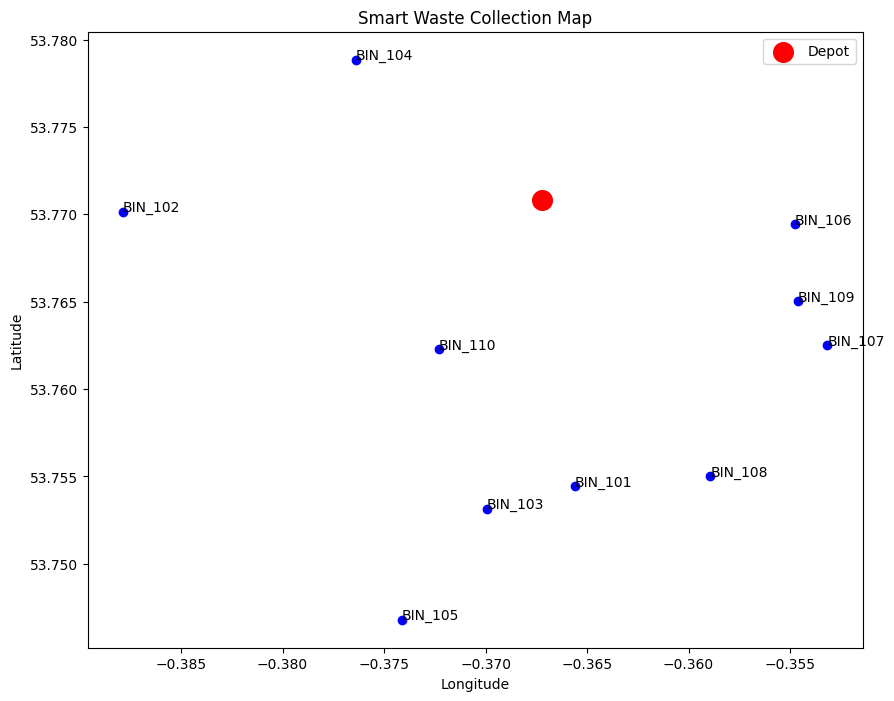

In [20]:
plt.figure(figsize=(10,8))

# Plot depot
plt.scatter(DEPOT[1], DEPOT[0], color='red', s=200, label='Depot')

# Plot bins
for b in reports:
    plt.scatter(b["coordinates"][1], b["coordinates"][0], color='blue')
    plt.text(b["coordinates"][1], b["coordinates"][0], b["bin_id"])

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Smart Waste Collection Map")
plt.legend()
plt.show()


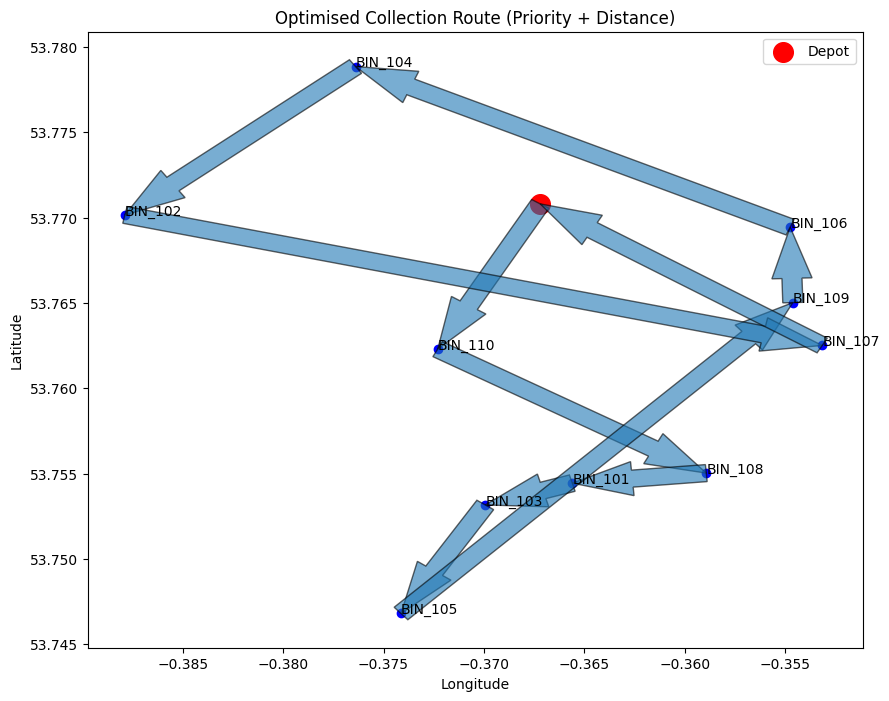

In [21]:
plt.figure(figsize=(10,8))

# Plot depot
plt.scatter(DEPOT[1], DEPOT[0], color='red', s=200, label='Depot')

# Plot bins
for b in reports:
    plt.scatter(b["coordinates"][1], b["coordinates"][0], color='blue')
    plt.text(b["coordinates"][1], b["coordinates"][0], b["bin_id"])

# Draw route path
current = DEPOT
for b in route:
    plt.arrow(current[1], current[0],
              b["coordinates"][1] - current[1],
              b["coordinates"][0] - current[0],
              length_includes_head=True,
              head_width=0.002,
              alpha=0.6)
    current = b["coordinates"]

# Return to depot
plt.arrow(current[1], current[0],
          DEPOT[1] - current[1],
          DEPOT[0] - current[0],
          length_includes_head=True,
          head_width=0.002,
          alpha=0.6)

plt.title("Optimised Collection Route (Priority + Distance)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()


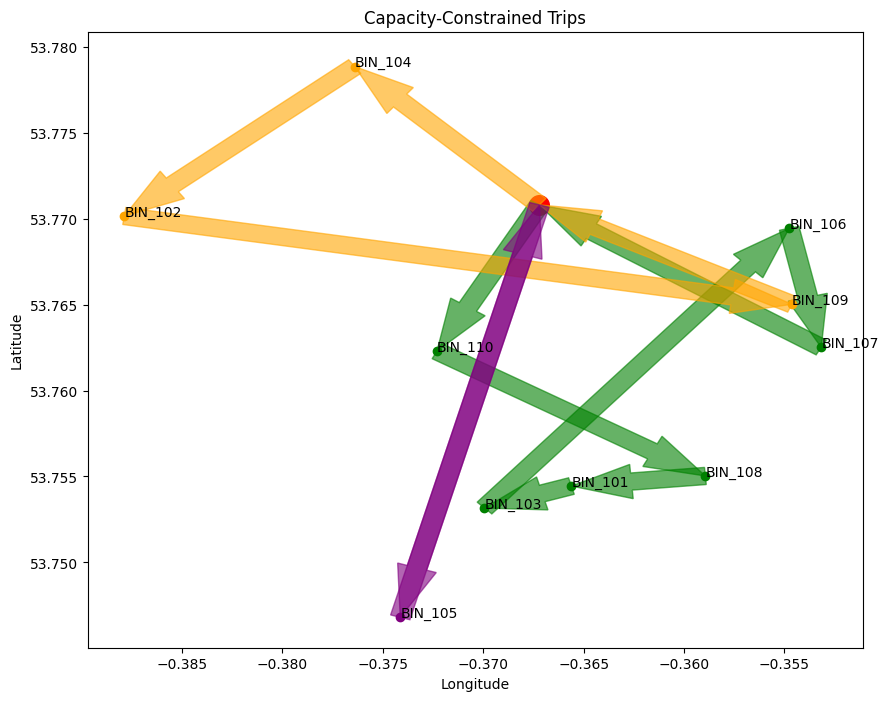

In [22]:
colors = ['green', 'orange', 'purple']

plt.figure(figsize=(10,8))

plt.scatter(DEPOT[1], DEPOT[0], color='red', s=200, label='Depot')

for i, trip in enumerate(all_trips):
    current = DEPOT
    
    for b in trip["bins"]:
        plt.scatter(b["coordinates"][1], b["coordinates"][0], color=colors[i])
        plt.text(b["coordinates"][1], b["coordinates"][0], b["bin_id"])
        
        plt.arrow(current[1], current[0],
                  b["coordinates"][1] - current[1],
                  b["coordinates"][0] - current[0],
                  length_includes_head=True,
                  head_width=0.002,
                  alpha=0.6,
                  color=colors[i])
        
        current = b["coordinates"]
    
    # return to depot
    plt.arrow(current[1], current[0],
              DEPOT[1] - current[1],
              DEPOT[0] - current[0],
              length_includes_head=True,
              head_width=0.002,
              alpha=0.6,
              color=colors[i])

plt.title("Capacity-Constrained Trips")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [23]:
def compute_priority_only_distance(reports, depot):
    ordered = sorted(reports, key=lambda x: x["priority_score"], reverse=True)
    current = depot
    total = 0
    
    for b in ordered:
        total += haversine(current, b["coordinates"])
        current = b["coordinates"]
        
    total += haversine(current, depot)
    return total


def compute_priority_distance_route(reports, depot):
    remaining = reports.copy()
    current = depot
    total = 0
    
    while remaining:
        scored = []
        for b in remaining:
            dist = haversine(current, b["coordinates"])
            score = dist / (b["priority_score"] + 0.01)
            scored.append((score, dist, b))
        
        scored.sort(key=lambda x: x[0])
        _, dist, chosen = scored[0]
        
        total += dist
        current = chosen["coordinates"]
        remaining.remove(chosen)
    
    total += haversine(current, depot)
    return total


In [24]:

priority_only_results = []
priority_distance_results = []
improvements = []

for i in range(10):
    
    random.seed(i)
    np.random.seed(i)
    
    # regenerate bins
    bins = [f"BIN_{100+j}" for j in range(10)]
    results = []
    
    for b in bins:
        img_path = random.choice(image_paths)
        results.append(process_bin(b, img_path))
    
    # assign coordinates
    for r in results:
        base = sector_coords[r["location"]]
        r["coordinates"] = (
            base[0] + random.uniform(-0.01, 0.01),
            base[1] + random.uniform(-0.01, 0.01)
        )
    
    po = compute_priority_only_distance(results, DEPOT)
    pd = compute_priority_distance_route(results, DEPOT)
    
    priority_only_results.append(po)
    priority_distance_results.append(pd)
    improvements.append((po - pd) / po * 100)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [25]:
print("Priority-only Mean Distance:", round(np.mean(priority_only_results),2))
print("Priority+Distance Mean Distance:", round(np.mean(priority_distance_results),2))
print("Average % Improvement:", round(np.mean(improvements),2))
print("Std Dev Improvement:", round(np.std(improvements),2))


Priority-only Mean Distance: 19.08
Priority+Distance Mean Distance: 11.43
Average % Improvement: 39.68
Std Dev Improvement: 7.11


In [26]:
def real_time_simulation_with_collection(steps=5, collect_top_k=3):

    current_bins = results.copy()

    for t in range(steps):
        print(f"\n===== TIME STEP {t+1} =====")

        # 1) Waste accumulation
        for b in current_bins:
            growth = random.uniform(1, 5)
            b["fill_level"] = min(100, b["fill_level"] + growth)

            predicted = predict_future_fill(
                current_fill=b["fill_level"],
                hour=(datetime.datetime.now().hour + t) % 24,
                day=0,
                weekend=0
            )
            b["predicted_fill"] = round(predicted, 1)

            priority, _ = calculate_priority_score(b["confidence"], b)
            b["priority_score"] = priority

        # 2) Sort priorities
        current_bins = sorted(current_bins, key=lambda x: x["priority_score"], reverse=True)

        # 3) Show Top bins
        print("\nTop 3 Priority Bins:")
        for b in current_bins[:3]:
            print(f"{b['bin_id']} | Fill={round(b['fill_level'],1)}% | Pred={b['predicted_fill']}% | Priority={b['priority_score']}")

        # 4) Critical alerts
        critical_bins = [b for b in current_bins if b["fill_level"] >= 90]
        if critical_bins:
            print("\n⚠ CRITICAL ALERT:")
            for b in critical_bins:
                print(f"{b['bin_id']} has exceeded 90% capacity!")

        # 5) Simulate collection of top-k bins (empty them)
        print(f"\n🚛 Collecting top {collect_top_k} bins...")
        for b in current_bins[:collect_top_k]:
            b["fill_level"] = random.uniform(0, 15)  # emptied
            b["last_collection_hours"] = 0

        # Increment collection hours for all others
        for b in current_bins[collect_top_k:]:
            b["last_collection_hours"] += 1


In [27]:
real_time_simulation_with_collection(steps=5, collect_top_k=3)



===== TIME STEP 1 =====

Top 3 Priority Bins:
BIN_107 | Fill=86.8% | Pred=93.0% | Priority=0.75
BIN_102 | Fill=77.0% | Pred=85.7% | Priority=0.67
BIN_100 | Fill=89.5% | Pred=95.5% | Priority=0.59

🚛 Collecting top 3 bins...

===== TIME STEP 2 =====

Top 3 Priority Bins:
BIN_104 | Fill=65.6% | Pred=55.4% | Priority=0.57
BIN_103 | Fill=59.3% | Pred=63.5% | Priority=0.57
BIN_109 | Fill=70.8% | Pred=76.7% | Priority=0.52

🚛 Collecting top 3 bins...

===== TIME STEP 3 =====

Top 3 Priority Bins:
BIN_105 | Fill=72.4% | Pred=76.2% | Priority=0.51
BIN_108 | Fill=32.7% | Pred=38.5% | Priority=0.32
BIN_101 | Fill=45.9% | Pred=54.3% | Priority=0.3

🚛 Collecting top 3 bins...

===== TIME STEP 4 =====

Top 3 Priority Bins:
BIN_106 | Fill=22.8% | Pred=27.3% | Priority=0.22
BIN_102 | Fill=22.6% | Pred=27.8% | Priority=0.15
BIN_100 | Fill=19.1% | Pred=25.4% | Priority=0.14

🚛 Collecting top 3 bins...

===== TIME STEP 5 =====

Top 3 Priority Bins:
BIN_108 | Fill=21.2% | Pred=26.9% | Priority=0.14
BIN_

In [28]:
data_rows = []

for bin_id in range(1, 51):  # 50 bins history
    fill = random.randint(5, 30)
    growth_rate = random.uniform(0.2, 1.8)  # each bin behaves differently

    for hour in range(0, 168):  # 7 days hourly
        hour_of_day = hour % 24
        day = hour // 24
        weekend = 1 if day in [5, 6] else 0

        # growth pattern (weekday/weekend + daily cycle)
        base_growth = growth_rate + (0.6 if weekend else 0.2)
        daily_cycle = 0.5 * np.sin(2 * np.pi * hour_of_day / 24)
        noise = random.uniform(-1.5, 1.5)

        fill = fill + base_growth + daily_cycle + noise
        fill = max(0, min(100, fill))

        # random collection event (bin emptied)
        if random.random() < 0.03:  # 3% chance per hour
            fill = random.uniform(0, 15)

        # target: 6 hours ahead
        future_fill = fill + 6 * base_growth + random.uniform(-3, 3)
        future_fill = max(0, min(100, future_fill))

        data_rows.append([fill, hour_of_day, day, weekend, future_fill])

import pandas as pd
df = pd.DataFrame(data_rows, columns=["fill_level","hour_of_day","day","weekend","future_fill"])

X = df[["fill_level","hour_of_day","day","weekend"]]
y = df["future_fill"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

forecast_model = RandomForestRegressor(n_estimators=200, random_state=42)
forecast_model.fit(X_train, y_train)

preds = forecast_model.predict(X_test)
print("Forecast MAE:", round(mean_absolute_error(y_test, preds),2))
print("Forecast R2:", round(r2_score(y_test, preds),2))


Forecast MAE: 2.48
Forecast R2: 0.99


**Build OR load the road network graph (Hull)**

In [32]:
#This will download roads from OpenStreetMap the first time, then reuse a saved graph file.
# Depot (Hull)
DEPOT = (53.7708, -0.3672)

# Save graph so you don't download every time
GRAPH_PATH = "../data/iot/hull_drive.graphml"
os.makedirs("../data/iot", exist_ok=True)

if os.path.exists(GRAPH_PATH):
    G = ox.load_graphml(GRAPH_PATH)
    print("Loaded saved road graph:", GRAPH_PATH)
else:
    # 5km radius around depot (increase to 8000 if you want larger)
    G = ox.graph_from_point(DEPOT, dist=5000, network_type="drive")
    ox.save_graphml(G, GRAPH_PATH)
    print("Downloaded + saved road graph:", GRAPH_PATH)

print("Graph:", len(G.nodes), "nodes,", len(G.edges), "edges")

Downloaded + saved road graph: ../data/iot/hull_drive.graphml
Graph: 9540 nodes, 20498 edges


**Distance functions (real road distance)**

In [33]:
#This is the key replacement for Haversine.
def nearest_node(G, coord):
    # OSMnx expects (X=lon, Y=lat)
    lat, lon = coord
    return ox.distance.nearest_nodes(G, lon, lat)

def road_distance_km(G, coord1, coord2):
    """
    Returns shortest-path driving distance (km) using road network.
    Fallback: if route fails, returns Haversine distance instead.
    """
    try:
        n1 = nearest_node(G, coord1)
        n2 = nearest_node(G, coord2)
        dist_m = nx.shortest_path_length(G, n1, n2, weight="length")
        return dist_m / 1000.0
    except Exception:
        # fallback to haversine if something goes wrong
        return haversine(coord1, coord2)

In [34]:
# Make sure you already have: reports = results.copy() and each report has "coordinates"
depot_node = nearest_node(G, DEPOT)

for b in reports:
    b["node"] = nearest_node(G, b["coordinates"])

print("Depot node:", depot_node)
print("Example bin node:", reports[0]["bin_id"], reports[0]["node"])

Depot node: 252419541
Example bin node: BIN_108 206287331


In [35]:
#This is your main route optimisation but now based on roads.
remaining = reports.copy()
current_node = depot_node
route = []
total_distance = 0

while remaining:
    scored = []
    for b in remaining:
        dist_km = nx.shortest_path_length(G, current_node, b["node"], weight="length") / 1000.0
        score = dist_km / (b["priority_score"] + 0.01)
        scored.append((score, dist_km, b))

    scored.sort(key=lambda x: x[0])
    _, chosen_dist, chosen_bin = scored[0]

    route.append(chosen_bin)
    total_distance += chosen_dist
    current_node = chosen_bin["node"]
    remaining.remove(chosen_bin)

# Return to depot
total_distance += nx.shortest_path_length(G, current_node, depot_node, weight="length") / 1000.0

print("\n--- Road-Network Optimised Collection Route (Priority + Distance) ---")
for i, b in enumerate(route, 1):
    print(f"{i}. {b['bin_id']} | {b['location']} | PredFill={b.get('predicted_fill','-')} | Priority={b['priority_score']}")

print("\nTotal Road Travel Distance (km):", round(total_distance, 2))


--- Road-Network Optimised Collection Route (Priority + Distance) ---
1. BIN_109 | Sector A | PredFill=91.9 | Priority=0.62
2. BIN_106 | Sector A | PredFill=47.0 | Priority=0.44
3. BIN_108 | Sector A | PredFill=95.5 | Priority=0.77
4. BIN_101 | Sector C | PredFill=47.4 | Priority=0.44
5. BIN_103 | Sector A | PredFill=33.8 | Priority=0.47
6. BIN_110 | Sector B | PredFill=91.9 | Priority=0.67
7. BIN_104 | Sector B | PredFill=84.1 | Priority=0.72
8. BIN_102 | Sector B | PredFill=68.8 | Priority=0.41
9. BIN_105 | Sector C | PredFill=61.7 | Priority=0.48
10. BIN_107 | Sector A | PredFill=25.1 | Priority=0.18

Total Road Travel Distance (km): 19.86


**Priority-only route distance using road distance**

In [36]:
priority_only = sorted(reports, key=lambda x: x["priority_score"], reverse=True)

dist_priority_only = 0
current_node = depot_node

for b in priority_only:
    dist_priority_only += nx.shortest_path_length(G, current_node, b["node"], weight="length") / 1000.0
    current_node = b["node"]

# Return depot
dist_priority_only += nx.shortest_path_length(G, current_node, depot_node, weight="length") / 1000.0

print("Road Distance (Priority-only route):", round(dist_priority_only, 2), "km")
print("Road Distance (Priority+Distance route):", round(total_distance, 2), "km")
print("Savings (km):", round(dist_priority_only - total_distance, 2))

Road Distance (Priority-only route): 26.19 km
Road Distance (Priority+Distance route): 19.86 km
Savings (km): 6.33


**Capacity-constrained routing with road distance (Trips)**

In [37]:
TRUCK_CAPACITY = 300

remaining = reports.copy()
current_node = depot_node
current_load = 0
total_distance_capacity = 0

trips = []
trip_bins = []

while remaining:
    feasible = [b for b in remaining if current_load + b["fill_level"] <= TRUCK_CAPACITY]

    # If no feasible bins, close trip and return depot
    if not feasible:
        total_distance_capacity += nx.shortest_path_length(G, current_node, depot_node, weight="length") / 1000.0
        trips.append((trip_bins, current_load))
        trip_bins = []
        current_node = depot_node
        current_load = 0
        continue

    scored = []
    for b in feasible:
        dist_km = nx.shortest_path_length(G, current_node, b["node"], weight="length") / 1000.0
        score = dist_km / (b["priority_score"] + 0.01)
        scored.append((score, dist_km, b))

    scored.sort(key=lambda x: x[0])
    _, chosen_dist, chosen = scored[0]

    trip_bins.append(chosen)
    total_distance_capacity += chosen_dist
    current_node = chosen["node"]
    current_load += chosen["fill_level"]
    remaining.remove(chosen)

# close final trip
total_distance_capacity += nx.shortest_path_length(G, current_node, depot_node, weight="length") / 1000.0
if trip_bins:
    trips.append((trip_bins, current_load))

print("\n--- Capacity-Constrained Collection Plan (Road Network) ---")
for i, (bins_trip, load_used) in enumerate(trips, 1):
    print(f"\nTrip {i} | Load used: {load_used}/{TRUCK_CAPACITY}")
    for j, b in enumerate(bins_trip, 1):
        print(f"  {j}. {b['bin_id']} | {b['location']} | Fill={b['fill_level']}% | Priority={b['priority_score']}")

print("\nTotal Trips:", len(trips))
print("Total Road Travel Distance (km):", round(total_distance_capacity, 2))


--- Capacity-Constrained Collection Plan (Road Network) ---

Trip 1 | Load used: 299/300
  1. BIN_109 | Sector A | Fill=86% | Priority=0.62
  2. BIN_106 | Sector A | Fill=38% | Priority=0.44
  3. BIN_108 | Sector A | Fill=90% | Priority=0.77
  4. BIN_101 | Sector C | Fill=37% | Priority=0.44
  5. BIN_103 | Sector A | Fill=27% | Priority=0.47
  6. BIN_107 | Sector A | Fill=21% | Priority=0.18

Trip 2 | Load used: 256/300
  1. BIN_110 | Sector B | Fill=86% | Priority=0.67
  2. BIN_104 | Sector B | Fill=78% | Priority=0.72
  3. BIN_102 | Sector B | Fill=92% | Priority=0.41

Trip 3 | Load used: 64/300
  1. BIN_105 | Sector C | Fill=64% | Priority=0.48

Total Trips: 3
Total Road Travel Distance (km): 24.84


**Helper: Build path geometry from nodes**

In [39]:
import matplotlib.pyplot as plt

def build_route_nodes(G, start_node, bins_in_order, end_node=None):
    """
    Creates a full node-by-node path by chaining shortest paths between bins.
    bins_in_order: list of bin dicts (each must have "node")
    """
    full_path = []
    current = start_node

    for b in bins_in_order:
        segment = nx.shortest_path(G, current, b["node"], weight="length")
        if full_path:
            full_path.extend(segment[1:])  # avoid duplicates
        else:
            full_path.extend(segment)
        current = b["node"]

    if end_node is not None:
        segment = nx.shortest_path(G, current, end_node, weight="length")
        full_path.extend(segment[1:])

    return full_path

**Plot: Priority + Distance road route (single route)**

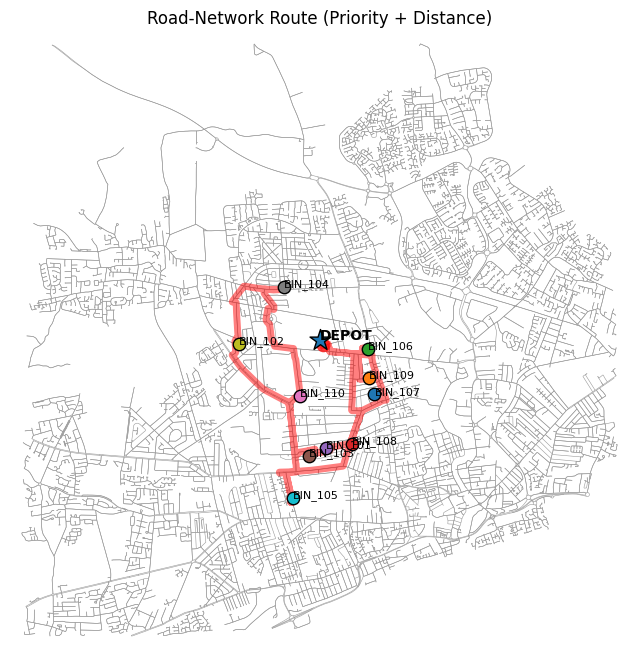

In [49]:
# Build node path for the route you computed earlier (priority+distance route)
route_nodes = build_route_nodes(G, depot_node, route, end_node=depot_node)

# Plot base graph
fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_linewidth=0.4,
    bgcolor="white",
    show=False,
    close=False
)

# Plot the route on top
ox.plot_graph_route(
    G,
    route_nodes,
    route_linewidth=5,
    route_color="red",
    node_size=0,
    ax=ax,
    show=False,
    close=False
)

# Plot depot + bin points
depot_lat, depot_lon = DEPOT
ax.scatter(depot_lon, depot_lat, marker="*", s=250, edgecolor="black", zorder=5)
ax.text(depot_lon, depot_lat, "DEPOT", fontsize=10, fontweight="bold", zorder=6)

for b in route:
    lat, lon = b["coordinates"]
    ax.scatter(lon, lat, s=80, edgecolor="black", zorder=5)
    ax.text(lon, lat, b["bin_id"], fontsize=8, zorder=6)

ax.set_title("Road-Network Route (Priority + Distance)")
plt.show()

**Plot: Capacity-constrained trips on roads (Trip 1/2/3…)**

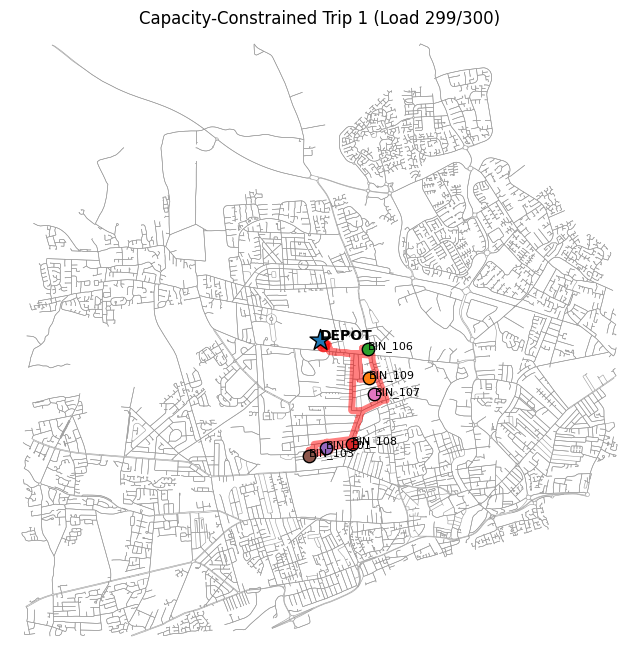

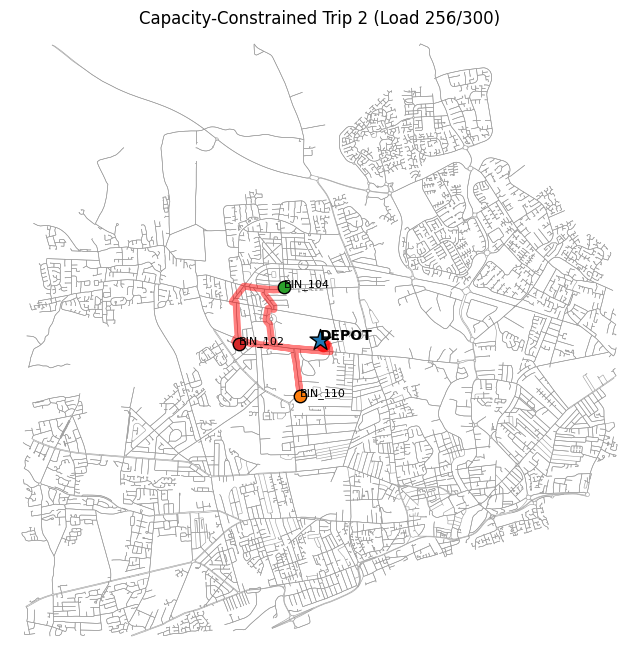

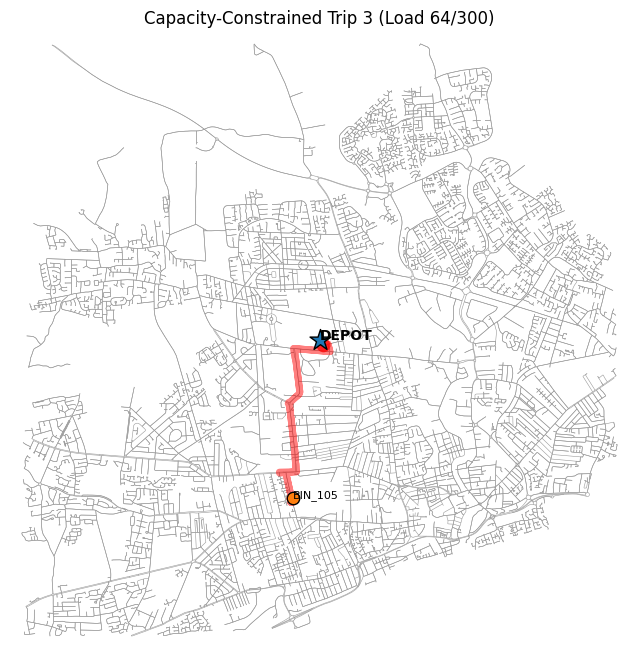

In [50]:
for trip_idx, (bins_trip, load_used) in enumerate(trips, 1):
    trip_nodes = build_route_nodes(G, depot_node, bins_trip, end_node=depot_node)

    fig, ax = ox.plot_graph(
        G,
        node_size=0,
        edge_linewidth=0.4,
        bgcolor="white",
        show=False,
        close=False
    )

    ox.plot_graph_route(
        G,
        trip_nodes,
        route_linewidth=5,
        route_color="red",
        node_size=0,
        ax=ax,
        show=False,
        close=False
    )

    # Depot marker
    depot_lat, depot_lon = DEPOT
    ax.scatter(depot_lon, depot_lat, marker="*", s=250, edgecolor="black", zorder=5)
    ax.text(depot_lon, depot_lat, "DEPOT", fontsize=10, fontweight="bold", zorder=6)

    # Trip bins
    for b in bins_trip:
        lat, lon = b["coordinates"]
        ax.scatter(lon, lat, s=80, edgecolor="black", zorder=5)
        ax.text(lon, lat, b["bin_id"], fontsize=8, zorder=6)

    ax.set_title(f"Capacity-Constrained Trip {trip_idx} (Load {load_used}/300)")
    plt.show()

**Environmental impact modelling layer**

**Define fuel + CO₂ factors (clearly stated assumptions)**

In [55]:
import numpy as np
import pandas as pd

# --- Assumptions (document these in dissertation) ---
# Typical waste collection truck fuel economy is often ~30–60 L/100km depending on load/urban stop-start.
# We will use a conservative mid value:
FUEL_L_PER_100KM = 45.0

# Diesel CO2 factor (kg CO2 per litre of diesel burned)
CO2_KG_PER_LITER = 2.68

def fuel_liters(distance_km, fuel_l_per_100km=FUEL_L_PER_100KM):
    return (fuel_l_per_100km / 100.0) * distance_km

def co2_kg(distance_km, fuel_l_per_100km=FUEL_L_PER_100KM, co2_kg_per_l=CO2_KG_PER_LITER):
    return fuel_liters(distance_km, fuel_l_per_100km) * co2_kg_per_l

**Convert multi-run routing distances → fuel + CO₂ (per run)**

In [56]:
po = np.array(priority_only_results)       # Priority-only distances (km)
pd_ = np.array(priority_distance_results)  # Priority+Distance distances (km)

summary = pd.DataFrame({
    "run": np.arange(1, len(po)+1),
    "priority_only_km": po,
    "priority_distance_km": pd_,
})

summary["km_saved"] = summary["priority_only_km"] - summary["priority_distance_km"]
summary["fuel_saved_L"] = summary["km_saved"].apply(fuel_liters)
summary["co2_saved_kg"] = summary["km_saved"].apply(co2_kg)

summary.head()

,run,priority_only_km,priority_distance_km,km_saved,fuel_saved_L,co2_saved_kg
0,1,19.384653,11.826467,7.558187,3.401184,9.115173
1,2,17.511759,11.243265,6.268493,2.820822,7.559803
2,3,18.755399,10.822764,7.932635,3.569686,9.566758
3,4,13.879548,9.943673,3.935875,1.771144,4.746665
4,5,20.684214,10.553966,10.130248,4.558612,12.217080


In [57]:
mean_km_saved = summary["km_saved"].mean()
std_km_saved = summary["km_saved"].std()

mean_fuel_saved = summary["fuel_saved_L"].mean()
std_fuel_saved = summary["fuel_saved_L"].std()

mean_co2_saved = summary["co2_saved_kg"].mean()
std_co2_saved = summary["co2_saved_kg"].std()

print("=== Environmental Impact Summary (Mean ± Std across runs) ===")
print(f"Distance saved: {mean_km_saved:.2f} ± {std_km_saved:.2f} km per routing cycle")
print(f"Fuel saved:     {mean_fuel_saved:.2f} ± {std_fuel_saved:.2f} L per routing cycle")
print(f"CO2 saved:      {mean_co2_saved:.2f} ± {std_co2_saved:.2f} kg CO2 per routing cycle")

=== Environmental Impact Summary (Mean ± Std across runs) ===
Distance saved: 7.64 ± 1.98 km per routing cycle
Fuel saved:     3.44 ± 0.89 L per routing cycle
CO2 saved:      9.22 ± 2.39 kg CO2 per routing cycle


**Scale to daily / weekly / yearly savings**

In [58]:
ROUTES_PER_DAY = 1  # change if council optimises multiple times/day
DAYS_PER_YEAR = 365

annual_km_saved = mean_km_saved * ROUTES_PER_DAY * DAYS_PER_YEAR
annual_fuel_saved = mean_fuel_saved * ROUTES_PER_DAY * DAYS_PER_YEAR
annual_co2_saved = mean_co2_saved * ROUTES_PER_DAY * DAYS_PER_YEAR

print("=== Scaled Estimate (using assumptions) ===")
print(f"Annual distance saved: {annual_km_saved:.0f} km/year")
print(f"Annual fuel saved:     {annual_fuel_saved:.0f} L/year")
print(f"Annual CO2 saved:      {annual_co2_saved:.0f} kg CO2/year ({annual_co2_saved/1000:.2f} tonnes)")

=== Scaled Estimate (using assumptions) ===
Annual distance saved: 2790 km/year
Annual fuel saved:     1255 L/year
Annual CO2 saved:      3365 kg CO2/year (3.36 tonnes)


**Plot: CO₂ savings per run**

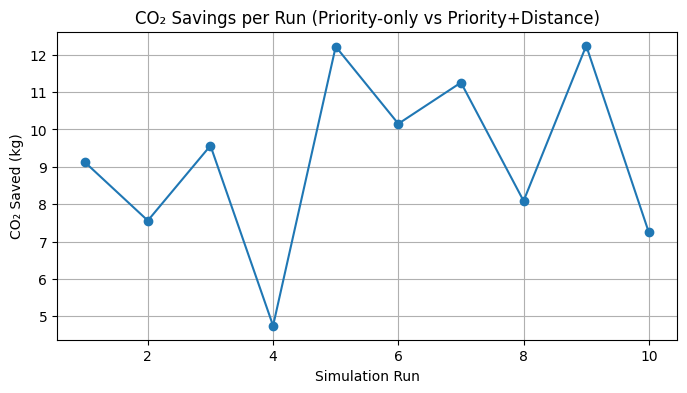

In [61]:
plt.figure(figsize=(8,4))
plt.plot(summary["run"], summary["co2_saved_kg"], marker="o")
plt.xlabel("Simulation Run")
plt.ylabel("CO₂ Saved (kg)")
plt.title("CO₂ Savings per Run (Priority-only vs Priority+Distance)")
plt.grid(True)
plt.show()

**Sensitivity analysis table (30 / 45 / 60 L per 100 km)**

In [62]:
fuel_scenarios = [30, 45, 60]  # L/100km (efficient, baseline, heavy stop-start)

sens_rows = []
for f in fuel_scenarios:
    mean_fuel = summary["km_saved"].apply(lambda km: fuel_liters(km, f)).mean()
    std_fuel  = summary["km_saved"].apply(lambda km: fuel_liters(km, f)).std()
    
    mean_co2  = summary["km_saved"].apply(lambda km: co2_kg(km, f)).mean()
    std_co2   = summary["km_saved"].apply(lambda km: co2_kg(km, f)).std()
    
    sens_rows.append({
        "Fuel Assumption (L/100km)": f,
        "Mean Fuel Saved (L/run)": round(mean_fuel, 2),
        "Std Fuel Saved (L/run)": round(std_fuel, 2),
        "Mean CO2 Saved (kg/run)": round(mean_co2, 2),
        "Std CO2 Saved (kg/run)": round(std_co2, 2),
    })

sensitivity_df = pd.DataFrame(sens_rows)
sensitivity_df

,Fuel Assumption (L/100km),Mean Fuel Saved (L/run),Std Fuel Saved (L/run),Mean CO2 Saved (kg/run),Std CO2 Saved (kg/run)
0,30,2.29,0.59,6.15,1.59
1,45,3.44,0.89,9.22,2.39
2,60,4.59,1.19,12.29,3.18


**Sensitivity analysis table (30 / 45 / 60 L per 100 km)**

In [63]:
ROUTES_PER_DAY = 1
DAYS_PER_YEAR = 365

annual_rows = []
for f in fuel_scenarios:
    mean_fuel_saved = summary["km_saved"].apply(lambda km: fuel_liters(km, f)).mean()
    mean_co2_saved  = summary["km_saved"].apply(lambda km: co2_kg(km, f)).mean()
    
    annual_rows.append({
        "Fuel Assumption (L/100km)": f,
        "Annual Fuel Saved (L/year)": round(mean_fuel_saved * ROUTES_PER_DAY * DAYS_PER_YEAR, 0),
        "Annual CO2 Saved (kg/year)": round(mean_co2_saved * ROUTES_PER_DAY * DAYS_PER_YEAR, 0),
        "Annual CO2 Saved (tonnes/year)": round((mean_co2_saved * ROUTES_PER_DAY * DAYS_PER_YEAR)/1000, 2),
    })

annual_sensitivity_df = pd.DataFrame(annual_rows)
annual_sensitivity_df

,Fuel Assumption (L/100km),Annual Fuel Saved (L/year),Annual CO2 Saved (kg/year),Annual CO2 Saved (tonnes/year)
0,30,837.0,2243.0,2.24
1,45,1255.0,3365.0,3.36
2,60,1674.0,4486.0,4.49


**Plot: CO₂ saved under different fuel assumptions**

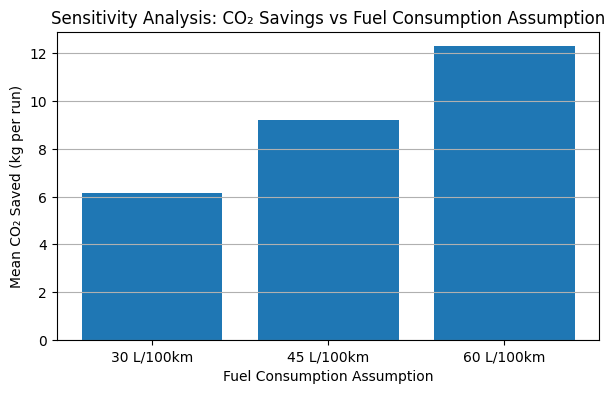

In [64]:

means = []
labels = []
for f in fuel_scenarios:
    mean_co2 = summary["km_saved"].apply(lambda km: co2_kg(km, f)).mean()
    means.append(mean_co2)
    labels.append(f"{f} L/100km")

plt.figure(figsize=(7,4))
plt.bar(labels, means)
plt.xlabel("Fuel Consumption Assumption")
plt.ylabel("Mean CO₂ Saved (kg per run)")
plt.title("Sensitivity Analysis: CO₂ Savings vs Fuel Consumption Assumption")
plt.grid(axis="y")
plt.show()